In [1]:
import re
import matplotlib.pyplot as plt
from spyplotter.powr import wrplot_to_tex,search_and_replace_math

In [6]:
test_string = '&I \{a\|b\} a &H d  &M #b# \, M\S log &R g &N'
test_string = '&0 HELLO'
test_string2 = '\(k&Ha&Tx&M\) n&Hor&Mm&Ha&Tl&Mhj'

Text(0.5, 0.5, ' HELLO')

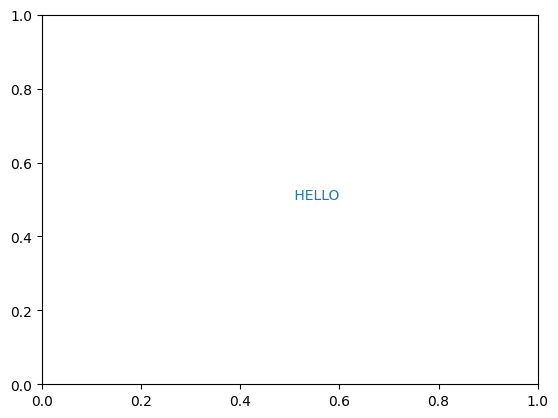

In [7]:
#new_string = search_and_replace_math(test_string,'\\\S', '\_\\\odot')
#print(new_string)
new_string,dict_kwargs = wrplot_to_tex(test_string)
#print(new_string)
plt.text(0.5,0.5,new_string,fontdict=dict_kwargs)

# Obvious math environment
Change \\\\( \\\)to \\\$...\\$

In [20]:
modified_string1 = re.sub(r'\\\((.*?)\\\)', r'$\1$', test_string)

In [21]:
modified_string1

'$k&Ha&Tda\\,x&M$ n&Ho\\,m&Mm#a#a&Tl&M \\{ab\\|a&Hb&Ma\\}'

In [42]:
modified_string2 = re.sub(r'\\\((.*?)\\\)', r'$\1$', test_string2)

In [43]:
modified_string2

'$k&Ha&Tx&M$ n&Hor&Mm&Ha&Tl&Mhj'

# Fractions
\\\{ ... \\\\| ...\\\} -> \\\frac\{ ..\} \{..\}

In [57]:
def search_replace_fractions(input_string):
    #split given string
    # Every odd index is math environment, and every even index is non-math environment
    string_list = re.split(r'\$(.*?)\$', input_string)
    new_string = ''
    for i in range(0,len(string_list)):
        if i%2==0:
            #non-math environment
            print('no math',string_list[i])
            nonmath_string = re.sub(r'\\\{(.*?)\\\|(.*?)\\\}',r'$\\frac{\1}{\2}$', string_list[i])
            new_string += nonmath_string
        else:
            #within math environment, add dollar signs again because they are not stored otherwise
            print('math',string_list[i])
            math_string = '$' + re.sub(r'\\\{(.*?)\\\|(.*?)\\\}', r'\\frac{\1}{\2}', string_list[i]) + '$'
            new_string += math_string
    return new_string

In [59]:
test_str = 'adkjjasak$\{ jasj\|jkasjk\} $aska\{ jasj\|jkasjk\} '
print(search_replace_fractions(test_str))

no math adkjjasak
math \{ jasj\|jkasjk\} 
no math aska\{ jasj\|jkasjk\} 
adkjjasak$\frac{ jasj}{jkasjk} $aska$\frac{ jasj}{jkasjk}$ 


# subscript: 
&T ... &M -> \\\$\_\\\$

In [45]:
def search_replace_subscript(input_string):
    #split given string
    # Every odd index is math environment, and every even index is non-math environment
    string_list = re.split(r'\$(.*?)\$', input_string)
   
    new_string = ''
    for i in range(0,len(string_list)):
        if i%2==0:
            #non-math environment
            nonmath_string = re.sub(r'&T(.*?)&M', r'$_{\1}$', string_list[i])
            new_string += nonmath_string
        else:
            #within math environment, add dollar signs again because they are not stored otherwise
            math_string = '$' + re.sub(r'&T(.*?)&M', r'_{\1}', string_list[i]) + '$'
            new_string += math_string
    return new_string

In [46]:
modified_string2 = search_replace_subscript(modified_string1)
print(f'Before: \n\t{modified_string1}')
print(f'After search+replace of subscript: \n\t{modified_string2}')

Before: 
	$k&Ha&Tx&M$ n&Hor&Mma&Tl&M
After search+replace of subscript: 
	$k&Ha_{x}$ n&Hor&Mma$_{l}$


# Superscript: 
&H ... &M -> \\\$\^\\\$

In [19]:
def search_replace_superscript(input_string):
    #split given string
    # Every odd index is math environment, and every even index is non-math environment
    string_list = re.split(r'\$(.*?)\$', input_string)
    new_string = ''
    for i in range(0,len(string_list)):
        if i%2==0:
            #non-math environment
            nonmath_string = re.sub(r'&H(.*?)&M', r'$^{\1}$', string_list[i])
            new_string += nonmath_string
        else:
            #within math environment, add dollar signs again because they are not stored otherwise
            math_string = '$' + re.sub(r'&H(.*?)&M', r'^{\1}', string_list[i]) + '$'
            new_string += math_string
    return new_string

In [25]:
modified_string3 = search_replace_superscript(modified_string2)
print(f'Before: \n\t{modified_string2}')
print(f'After search+replace of superscript: \n\t{modified_string3}')

Before: 
	$k&Ha_{x}$ n&Hor&Mma$_{l}$
After search+replace of subscript: 
	$k&Ha_{x}$ n$^{or}$ma$_{l}$


# Combination of subscript and superscript
&H ... &T ... &M -> \\\$\^...\_...\\\$

In [29]:
def search_replace_subsuperscript(input_string):
    #split given string
    # Every odd index is math environment, and every even index is non-math environment
    string_list = re.split(r'\$(.*?)\$', input_string)
    new_string = ''
    for i in range(0,len(string_list)):
        if i%2==0:
            #non-math environment
            print('no math',string_list[i])
            nonmath_string = re.sub(r'&H(?!&M)(.?)&T(.*?)&M', r'$^{\1}_{\2}$', string_list[i])
            new_string += nonmath_string
        else:
            #within math environment, add dollar signs again because they are not stored otherwise
            print('math',string_list[i])
            math_string = '$' + re.sub(r'&H(?!&M)(.?)&T(.*?)&M', r'^{\1}_{\2}', string_list[i]) + '$'
            print(math_string)
            new_string += math_string
    return new_string

In [30]:
modified_string4 = search_replace_subsuperscript(modified_string1)
print('before:\t', modified_string1)
print('result:\t', modified_string4)

no math 
math k&Ha&Tx&M
no math  n&Hor&Mma&Tl&M
before:	 $k&Ha&Tx&M$ n&Hor&Mma&Tl&M
result:	 $k^{a}_{x}$ n&Hor&Mma&Tl&M


In [34]:
modified_string4 = search_replace_subsuperscript(modified_string2)
print('before:\t', test_string2)
print('result:\t', modified_string4)

no math 
math k&Ha&Tx&M
no math  n&Hor&Mm&Ha&Tl&Mhj
before:	 \(k&Ha&Tx&M\) n&Hor&Mm&Ha&Tl&Mhj
result:	 $k^{a}_{x}$ n&Hor&Mm^{a}_{l}hj


# Italic font - math style
&R ... &N -> \\\$ .... \\\$ but only if not already in math environment

In [9]:
def search_replace_italicmath(input_string):
    #split given string
    # Every odd index is math environment, and every even index is non-math environment
    string_list = re.split(r'\$(.*?)\$', input_string)
    new_string = ''
    for i in range(0,len(string_list)):
        if i%2==0:
            #non-math environment
            nonmath_string = re.sub(r'&R(.*?)&N', r'$\1$', string_list[i])
            new_string += nonmath_string
        else:
            #within math environment, add dollar signs again because they are not stored otherwise
            math_string = '$' + re.sub(r'&R(.*?)&N', r'\1', string_list[i]) + '$'
            new_string += math_string
    return new_string

# Math symbols